### Authors

- Anna Beketova
- Shatu Ahmed

Target repository: [week5](https://gitlab.rlp.net/aibi_practical/aibi-ws-2024-25/-/tree/Embedding/week5)

# Labbook Week 5 - Embedding using Convolutional Layers with Sigmoid activation function and SGD optimizer

## Code

The dataset used during this week stems from the updated training set in the main branch, according to the provided [instructions](https://gitlab.rlp.net/a.hallab/aibi-ws-2024-25/-/blob/main/README.md?ref_type=heads)

### Data Preprocessing

In [2]:
import pandas as pd
from Bio import SeqIO
import csv

#read data
data = pd.read_csv("mapman_filtered.tsv", sep="\t")

# The dataset has already the form BINCODE - ID

bincode_dict = {} # dictionary to store all identifiers of each family


for index, row in data.iterrows():
    bincode = row['BINCODE'].strip("'")
    protein_id = row['IDENTIFIER'].strip("'").lower()
    if(protein_id):
        if(bincode not in bincode_dict):
            bincode_dict[bincode] = []
        bincode_dict[bincode].append(protein_id)


print(sum(len(v) for v in bincode_dict.values()))


proteins = "protein_filtered.fa"
protein_dict = {}

for record in SeqIO.parse(proteins, "fasta"):
    uniprot_id = record.id.split("|")[-1].lower()
    sequence = str(record.seq)
    protein_dict[uniprot_id] = sequence

grouped_dict = {}
for bincode, protein_ids in bincode_dict.items():
    sequences = [protein_dict[p] for p in protein_ids if p in protein_dict]
    if sequences:
        grouped_dict[bincode] = sequences
    else:
        grouped_dict[bincode] = []

result = "labeled_sequences_newdataset.csv"
with open(result, "w") as newfile:
    newfile.write("bincode,sequence\n")
    for bincode, sequences in grouped_dict.items():
        for seq in sequences:
            newfile.write(f"{bincode}, {seq}\n")


cleaned_rows = []

with open("labeled_sequences_newdataset.csv", "r") as infile:
    reader = csv.reader(infile)
    for row in reader:
        if len(row) > 2:
            bincode = row[0]
            sequence = ''.join(row[1:]).replace('"', '').replace("'", "") # Merge falsely added columns and clean quotes
            cleaned_rows.append([bincode, sequence])
        elif len(row) == 2:
            cleaned_rows.append(row)
        else:
            print(f"Skipping malformed row: {row}")


with open("NEW_labeled_sequences.csv", "w") as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_rows)

print("done")

40302
done


### Statistics for protein sequence lengths

In [6]:
import pandas as pd
import numpy as np

sequence_stat = pd.read_csv('NEW_labeled_sequences.csv')  

sequence_stat['sequence_length'] = sequence_stat['sequence'].apply(len)

average_length = sequence_stat['sequence_length'].mean()
median_length = sequence_stat['sequence_length'].median()
max_length = sequence_stat['sequence_length'].max()
min_length = sequence_stat['sequence_length'].min()

print("Statistics for protein sequence lengths:")
print(f"Average Length: {average_length}")
print(f"Median Length: {median_length}")
print(f"Maximum Length: {max_length}")
print(f"Minimum Length: {min_length}")


Statistics for protein sequence lengths:
Average Length: 479.29457595156566
Median Length: 447.0
Maximum Length: 4904
Minimum Length: 72


### Embedding step


In [13]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

labled = pd.read_csv("NEW_labeled_sequences.csv")

# Kidera factors (without processing of not-aminoacid characters)
kidera_factors = {
    'A': [-1.56, -1.67, -0.97, -0.27, -0.93, -0.78, -0.2, -0.08, 0.21, -0.48],
    'C': [0.12, -0.89, 0.45, -1.05, -0.71, 2.41, 1.52, -0.69, 1.13, 1.1],
    'D': [0.58, -0.22, -1.58, 0.81, -0.92, 0.15, -1.52, 0.47, 0.76, 0.7],
    'E': [-1.45, 0.19, -1.61, 1.17, -1.31, 0.4, 0.04, 0.38, -0.35, -0.12],
    'F': [-0.21, 0.98, -0.36, -1.43, 0.22, -0.81, 0.67, 1.1, 1.71, -0.44],
    'G': [1.46, -1.96, -0.23, -0.16, 0.1, -0.11, 1.32, 2.36, -1.66, 0.46],
    'H': [-0.41, 0.52, -0.28, 0.28, 1.61, 1.01, -1.85, 0.47, 1.13, 1.63],
    'I': [-0.73, -0.16, 1.79, -0.77, -0.54, 0.03, -0.83, 0.51, 0.66, -1.78],
    'K': [-0.34, 0.82, -0.23, 1.7, 1.54, -1.62, 1.15, -0.08, -0.48, 0.6],
    'L': [-1.04, 0, -0.24, -1.1, -0.55, -2.05, 0.96, -0.76, 0.45, 0.93],
    'M': [-1.4, 0.18, -0.42, -0.73, 2, 1.52, 0.26, 1.23, -1.27, 0.27],
    'N': [1.14, -0.07, -0.12, 0.81, 0.18, 0.37, -0.09, -2.3, 1.1, -1.73],
    'P': [2.06, 0.24, -1.15, -0.75, 0.88, -0.45, 0.84, -0.71, 0.74, -0.28],
    'Q': [-0.47, 1.27, 0.07, 1.1, 1.1, 0.59, 0.92, -1.15, -0.03, -2.33],
    'R': [0.22, -0.7, 1.37, 1.87, -1.7, 0.46, 0.84, -0.39, 0.23, 0.93],
    'S': [0.81, 1.27, 0.16, 0.42, -0.21, -0.43, 0.92, -1.15, -0.97, -0.23],
    'T': [0.26, -1.08, 1.21, 0.63, -0.1, 0.21, 0.24, -1.15, -0.56, 0.19],
    'V': [-0.74, -0.7, 2.04, -0.4, 0.5, -0.81, -1.07, 0.06, -2.3, -0.6],
    'W': [0.3, -0.71, -0.72, -1.57, -1.16, 0.57, -0.48, -0.4, -0.05, 0.53],
    'Y': [1.38, 2.1, 0.8, -0.56, 0, -0.68, -0.31, 1.03, -0.6, 0.53]
}

default_kidera_vector = [0.0] * 10  # Default vector (unknown letters are set to 0)

def compute_kidera_embedding(sequence, kidera_factors, default_kidera_vector):

    return np.array([kidera_factors.get(aa, default_kidera_vector) for aa in sequence])

def process_sequences(sequences, max_length, kidera_dict, default_vector):

    kidera_matrices = [compute_kidera_embedding(seq, kidera_dict, default_vector) for seq in sequences]
    return pad_sequences(kidera_matrices, maxlen=max_length, padding='post', dtype='float32')

sequences = labled['sequence'].tolist()

# Process the sequences and pad them
max_length = 3500 

kidera_encoded_sequences = process_sequences(sequences, max_length, kidera_factors, default_kidera_vector)

#Display processed sequences
#print(kidera_encoded_sequences[:2])
#print(labled.head())




### Labeling

Multi-label classification:

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd
import torch

data = pd.read_csv('NEW_labeled_sequences.csv')
# Convert 'bincode' into lists of labels
data['bincode'] = data['bincode'].str.split(', ')
mlb = MultiLabelBinarizer()
bincode_encoded = mlb.fit_transform(data['bincode'])  # Multi-hot encoding

print(len(bincode_encoded))


#print(len(kidera_encoded_sequences))
#print(len(labels_tensor))

# test output array
#print(bincode_encoded[400:420])

#print("Number of positive labels per class:", bincode_encoded.sum(axis=0))
#print("Number of positive labels per sample:", bincode_encoded.sum(axis=1))



40302


### Implementing a multi layered Convolutional Model


Class distribution in train set: tensor([ 502., 1212.,  796.,  646.,  356., 4783.,  403.,  645.,  312., 2096.,
        3216.,  208.,  761., 1982.,  813.,  300., 2985.,  507., 2437., 1391.,
         427.,  432.,  536.,  127.,  293.,  860.,  348.,  380., 1187., 1300.])
Class distribution in validation set: tensor([ 119.,  318.,  188.,  168.,   71., 1193.,  127.,  185.,   69.,  523.,
         794.,   47.,  212.,  498.,  217.,   91.,  761.,  137.,  599.,  320.,
          95.,  108.,  133.,   29.,   65.,  214.,   79.,   85.,  311.,  305.])


/tmp/ipykernel_201/3600647140.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
/tmp/ipykernel_201/3600647140.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
/tmp/ipykernel_201/3600647140.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
/tmp/ipykernel_201/3600647140.py:48: UserWarning: To copy construct from a tensor

labels_tensor shape: torch.Size([40302, 30])
Unique values in labels_tensor: tensor([0., 1.])
Input shape: torch.Size([40302, 10, 3500])
Labels shape: torch.Size([40302, 30])
Train set size: 32241
Validation set size: 8061
Epoch 1/40 - Train Loss: 0.1451, Val Loss: 0.1102
Epoch 2/40 - Train Loss: 0.1032, Val Loss: 0.0980
Epoch 3/40 - Train Loss: 0.0951, Val Loss: 0.0949
Epoch 4/40 - Train Loss: 0.0875, Val Loss: 0.0833
Epoch 5/40 - Train Loss: 0.0778, Val Loss: 0.0750
Epoch 6/40 - Train Loss: 0.0687, Val Loss: 0.0676
Epoch 7/40 - Train Loss: 0.0623, Val Loss: 0.0595
Epoch 8/40 - Train Loss: 0.0571, Val Loss: 0.0559
Epoch 9/40 - Train Loss: 0.0531, Val Loss: 0.0522
Epoch 10/40 - Train Loss: 0.0493, Val Loss: 0.0480
Epoch 11/40 - Train Loss: 0.0461, Val Loss: 0.0446
Epoch 12/40 - Train Loss: 0.0432, Val Loss: 0.0430
Epoch 13/40 - Train Loss: 0.0406, Val Loss: 0.0403
Epoch 14/40 - Train Loss: 0.0384, Val Loss: 0.0380
Epoch 15/40 - Train Loss: 0.0360, Val Loss: 0.0356
Epoch 16/40 - Train L

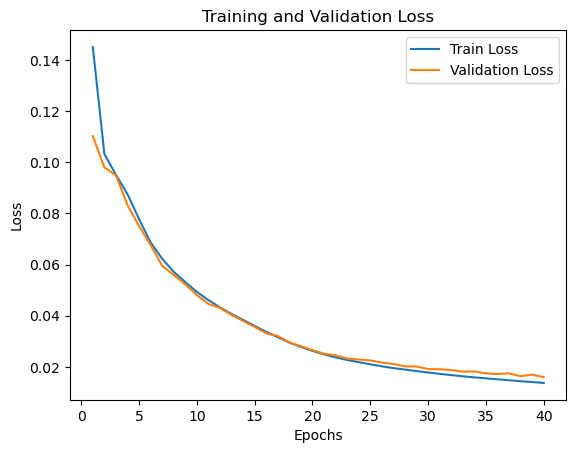

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split
from torchmetrics.classification import Precision, Recall, F1Score, MatthewsCorrCoef

kidera_encoded_sequences_tensor = torch.tensor(kidera_encoded_sequences, dtype=torch.float32)
labels_tensor = torch.tensor(bincode_encoded, dtype=torch.float32)  # labels are converted to float for BCE loss

# Permute the tensor to [num_sequences, num_features, sequence_length]
kidera_encoded_sequences_tensor = kidera_encoded_sequences_tensor.permute(0, 2, 1)


# Data split

# The code still splits the data randomly,
# the stratififed split will be implemented later

labels = labels_tensor.numpy()

# sum of labels across all samples for each class
label_sums = labels.sum(axis=0) # computes the sum of 1s along the rows

# Create indices and shuffle them
indices = np.arange(len(labels))
np.random.seed(42)
np.random.shuffle(indices)

# Split
split_point = int(0.8 * len(labels))  # 80-20 split
train_indices = indices[:split_point]
val_indices = indices[split_point:]

features_train, features_val = kidera_encoded_sequences_tensor[train_indices], kidera_encoded_sequences_tensor[val_indices]
labels_train, labels_val = labels_tensor[train_indices], labels_tensor[val_indices]

print("Class distribution in train set:", labels_train.sum(axis=0))
print("Class distribution in validation set:", labels_val.sum(axis=0))

    
# Convert back to PyTorch tensors
features_train_tensor = torch.tensor(features_train, dtype=torch.float32)
features_val_tensor = torch.tensor(features_val, dtype=torch.float32)
labels_train_tensor = torch.tensor(labels_train, dtype=torch.float32)
labels_val_tensor = torch.tensor(labels_val, dtype=torch.float32)


# Create TensorDatasets
train_dataset = TensorDataset(features_train_tensor, labels_train_tensor)
val_dataset = TensorDataset(features_val_tensor, labels_val_tensor)

# DataLoaders for batching
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


print("labels_tensor shape:", labels_tensor.shape)
print("Unique values in labels_tensor:", torch.unique(labels_tensor))
print("Input shape:", kidera_encoded_sequences_tensor.shape)
print("Labels shape:", labels_tensor.shape)
print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

num_classes = labels_tensor.shape[1]

# CNN Model defined (uncomment to add pooling)
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super(ConvolutionalNetwork, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=10, out_channels=32, kernel_size=7, stride=2)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)  # MaxPooling after conv1
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)  # MaxPooling after conv2
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)  # MaxPooling after conv3
        self.conv4 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.pool4 = nn.MaxPool1d(kernel_size=2, stride=2)  # MaxPooling after conv4
        self._calculate_conv_output_size()
        self.fc = nn.Linear(self.conv_output_size, num_classes)
        self.sigmoid = nn.Sigmoid()  # sigmoid activation 

    def _calculate_conv_output_size(self):
        dummy_input = torch.rand(1, 10, 3500)  # Simulate a single input
        dummy_output = self.conv1(dummy_input)
        dummy_output = self.pool1(dummy_output)  # Apply max pooling
        dummy_output = self.conv2(dummy_output)
        dummy_output = self.pool2(dummy_output)
        dummy_output = self.conv3(dummy_output)
        dummy_output = self.pool3(dummy_output)
        dummy_output = self.conv4(dummy_output)
        dummy_output = self.pool4(dummy_output)
        self.conv_output_size = dummy_output.size(1) * dummy_output.size(2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool3(x)
        x = self.conv4(x)
        x = self.pool4(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

# Model, loss function, and optimizer initialisation
model = ConvolutionalNetwork()
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

# Training
epochs = 40
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    # Training loop
    for batch in train_loader:
        batch_data, batch_labels = batch
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = loss_fn(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch_data, batch_labels = batch
            outputs = model(batch_data)
            loss = loss_fn(outputs, batch_labels)
            total_val_loss += loss.item()

    # Average losses
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Metric calculation after all epochs
print("\nCalculating metrics on the validation set...")

# Metrics initialization
precision_metric = Precision(task='multilabel', num_labels=num_classes, average='weighted')
recall_metric = Recall(task='multilabel', num_labels=num_classes, average='weighted')
f1_metric = F1Score(task='multilabel', num_labels=num_classes, average='weighted')
mcc_metric = MatthewsCorrCoef(task='multilabel', num_labels=num_classes)

y_test = []
y_pred = []

# Evaluate metrics on validation set
model.eval()
precision_metric.reset()
recall_metric.reset()
f1_metric.reset()
mcc_metric.reset()

with torch.no_grad():
    for batch in val_loader:
        batch_data, batch_labels = batch
        outputs = model(batch_data)
        predictions = (outputs > 0.5).int()  # Convert probabilities to binary and integer type
        batch_labels = batch_labels.int()   # Ensure labels are also integers
        y_test.extend(batch_labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

        
        # Update metrics with predictions and true labels
        precision_metric.update(predictions, batch_labels)
        recall_metric.update(predictions, batch_labels)
        f1_metric.update(predictions, batch_labels)
        mcc_metric.update(predictions, batch_labels)
        
y_test = np.array(y_test)
y_pred = np.array(y_pred)

# shapes of the predictions and true labels
print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

# Number of classes
print("Number of classes:", num_classes)

# Compute and display metrics
precision = precision_metric.compute()
recall = recall_metric.compute()
f1 = f1_metric.compute()
mcc = mcc_metric.compute()

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"MCC: {mcc:.4f}")

# Plot training and validation loss
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


## Experiment history

11.01.2025 changes:

- statistical data about the sequence length is calculated

Experiments with the length of 1500 aa:
<ul>
    <li> max pooling, batch size 64, lr = 0.0001, 40 epochs, adam optimizer:
    <li> Result: MCC: 0.9704, same tendency of the training and validation loss as last week
</ul>

<ul>
    <li> same hyperparameters, lr = 0.00001:
    <li> Result: MCC = 0.8790
</ul>

Experiments with the length of 2500 aa:

<ul>
    <li> max pooling, batch size 64, lr = 0.0001, 40 epochs, adam optimizer:
    <li> Result: little no difference with previous with lr = 0.0001, MCC = 0.9678
</ul> 

Experiments with the length of 3500 aa:

<ul>
    <li> max pooling, batch size 64, lr = 0.0001, 40 epochs, adam optimizer:
    <li> Result: validation loss increases slightly, MCC decreases slightly = 0,9610
</ul> 

<ul>
    <li> same hyperparameters, lr = 0.00001:
    <li> Result: no changes with previous lr = 0.00001 experiment, MCC = 0,8399
</ul> 

Experiments with the length of 4500 aa:

<ul>
    <li> max pooling, batch size 64, lr = 0.0001, 40 epochs, adam optimizer:
    <li> Result: much longer training time, MCC = 0.9707
</ul> 
 

12.01.2025 changes:

<ul>
    <li> length 822, SGD optimizer, lr = 0.01, 40 epochs, pooling, batch size 64:
    <li> Result: MCC: 0.2410
</ul>

<ul>
    <li> same parameters, lr = 0.001:
    <li> Result: metrics are 0.000
</ul>


<ul>
    <li> length 1500, SGD, 40 epochs, batch size 64, max pooling, lr=0.01, weight_decay=1e-4:
    <li> Result: MCC = 0.3488
</ul>

<ul>
    <li> same parameters, lr=0.1:
    <li> Result: MCC = 0.9328
</ul>

<ul>
    <li> length 2500, SGD, 40 epochs, batch size 64, max pooling, lr=0.1, weight_decay=1e-4:
    <li> Result: MCC = 0.9334
</ul>


<ul>
    <li> length 3500, SGD, 40 epochs, batch size 64, max pooling, lr=0.1, weight_decay=1e-4
    <li> Result: MCC = 0.9310
</ul>
<ul>
    <li> length 4900, SGD, 50 epochs, batch size 64, max pooling, lr=lr=0.0001
    <li> Result: MCC = 0.9694
</ul>